# 06: Final Kaggle Submission

**Combines men's + women's ensemble predictions for 2026 into one submission file.**

### Prerequisites
```
Men's:   04a -> 04b -> 05b_ensemble_modeling
Women's: 04a_W -> 04b_W -> 05b_W_ensemble_modeling
```

### Submission Format
- **132,133 rows** + header
- Season: 2026 only
- Men's (TeamID 1xxx) + Women's (TeamID 3xxx)
- Evaluation: **Brier Score** (lower = better)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from src.data_loader import load_sample_submission, load_teams, PROCESSED_DIR
from src.utils import validate_submission

SUB_DIR = PROCESSED_DIR.parent / 'submissions'

men_lookup = dict(zip(*[load_teams('M')[c] for c in ['TeamID', 'TeamName']]))
women_lookup = dict(zip(*[load_teams('W')[c] for c in ['TeamID', 'TeamName']]))
all_lookup = {**men_lookup, **women_lookup}

sample_sub = load_sample_submission(stage=2)
print(f"Sample submission: {len(sample_sub):,} rows")
print(f"Seasons: {sorted(sample_sub['ID'].str[:4].unique())}")

Sample submission: 132,133 rows
Seasons: ['2026']


---
## 1. Load Men's & Women's Predictions

In [19]:
# Load men's ensemble predictions (from 05b)
men_sub = pd.read_csv(SUB_DIR / 'submission_ensemble_v1.csv')
men_sub = men_sub[men_sub['ID'].apply(lambda x: int(x.split('_')[1]) < 3000)].copy()
print(f"Men's predictions:   {len(men_sub):,} rows")
print(f"  Mean: {men_sub['Pred'].mean():.3f}  Std: {men_sub['Pred'].std():.3f}")
print(f"  Range: [{men_sub['Pred'].min():.4f}, {men_sub['Pred'].max():.4f}]")

# Load women's ensemble predictions (from 05b_W)
women_sub = pd.read_csv(SUB_DIR / 'submission_women_ensemble_v1.csv')
print(f"\nWomen's predictions: {len(women_sub):,} rows")
print(f"  Mean: {women_sub['Pred'].mean():.3f}  Std: {women_sub['Pred'].std():.3f}")
print(f"  Range: [{women_sub['Pred'].min():.4f}, {women_sub['Pred'].max():.4f}]")

print(f"\nTotal: {len(men_sub) + len(women_sub):,} (expected: {len(sample_sub):,})")

Men's predictions:   66,430 rows
  Mean: 0.492  Std: 0.283
  Range: [0.0100, 0.9900]

Women's predictions: 65,703 rows
  Mean: 0.511  Std: 0.298
  Range: [0.0100, 0.9900]

Total: 132,133 (expected: 132,133)


---
## 2. Combine & Validate

In [20]:
# Combine men's + women's
submission = pd.concat([men_sub, women_sub], ignore_index=True)
submission = submission.sort_values('ID').reset_index(drop=True)

print(f"Combined: {len(submission):,} rows (expected: {len(sample_sub):,})")
print(f"Match: {len(submission) == len(sample_sub)}")

# Validate against sample
validation = validate_submission(submission, sample_sub)
print(f"Valid: {validation['valid']}")
if validation['errors']:
    print(f"ERRORS: {validation['errors']}")
if validation['warnings']:
    print(f"Warnings: {validation['warnings']}")

# Checks
missing_ids = set(sample_sub['ID']) - set(submission['ID'])
print(f"\nMissing IDs: {len(missing_ids)}")
print(f"NaN predictions: {submission['Pred'].isna().sum()}")
print(f"Out of range [0,1]: {((submission['Pred'] < 0) | (submission['Pred'] > 1)).sum()}")

# Gender breakdown
men_rows = submission[submission['ID'].apply(lambda x: int(x.split('_')[1]) < 3000)]
women_rows = submission[submission['ID'].apply(lambda x: int(x.split('_')[1]) >= 3000)]
print(f"\nMen's:   {len(men_rows):,} rows")
print(f"Women's: {len(women_rows):,} rows")

Combined: 132,133 rows (expected: 132,133)
Match: True
Valid: True

Missing IDs: 0
NaN predictions: 0
Out of range [0,1]: 0

Men's:   66,430 rows
Women's: 65,703 rows


---
## 3. Prediction Distributions

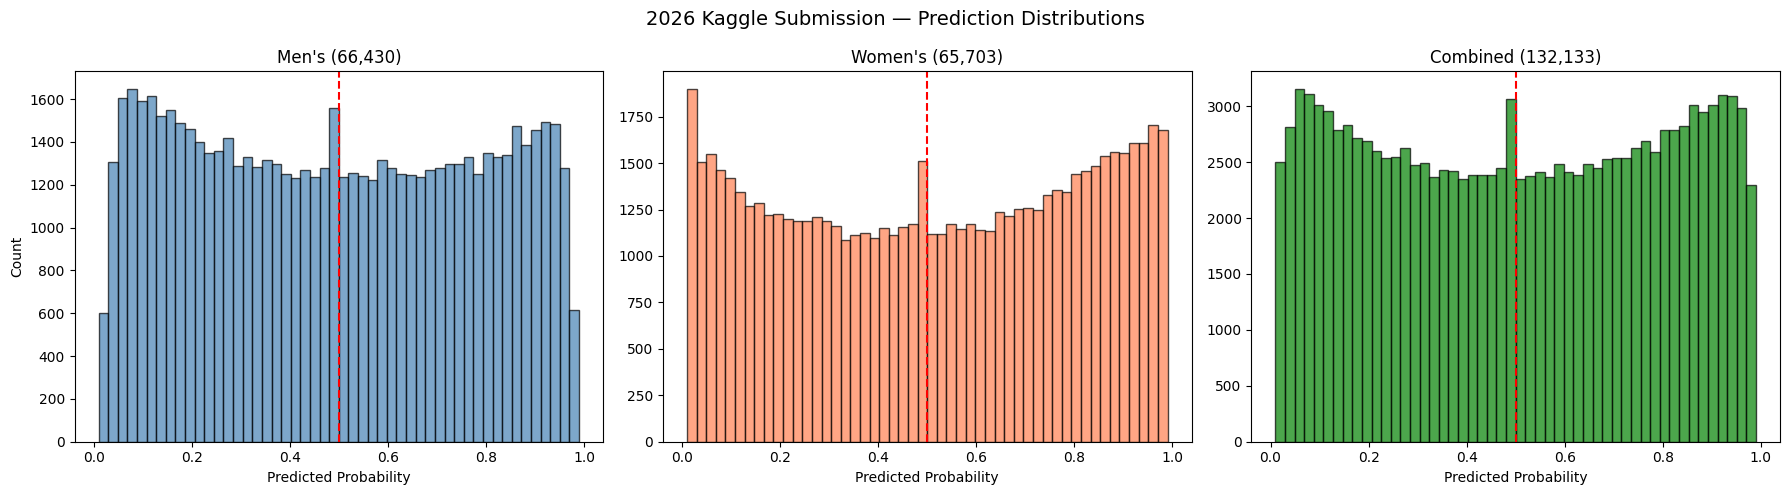

Very confident (>0.9 or <0.1): 26,593 (20.1%)
Uncertain (0.4-0.6):           25,150 (19.0%)


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(men_sub['Pred'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0.5, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title(f"Men's ({len(men_sub):,})")

axes[1].hist(women_sub['Pred'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(0.5, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_title(f"Women's ({len(women_sub):,})")

axes[2].hist(submission['Pred'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[2].axvline(0.5, color='red', linestyle='--')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_title(f"Combined ({len(submission):,})")

plt.suptitle('2026 Kaggle Submission — Prediction Distributions', fontsize=14)
plt.tight_layout()
plt.show()

very_confident = submission[(submission['Pred'] < 0.1) | (submission['Pred'] > 0.9)]
uncertain = submission[(submission['Pred'] > 0.4) & (submission['Pred'] < 0.6)]
print(f"Very confident (>0.9 or <0.1): {len(very_confident):,} ({100*len(very_confident)/len(submission):.1f}%)")
print(f"Uncertain (0.4-0.6):           {len(uncertain):,} ({100*len(uncertain)/len(submission):.1f}%)")

---
## 4. Sanity Check: Top Predictions

In [22]:
display_df = submission.copy()
parsed = display_df['ID'].str.split('_', expand=True)
display_df['Team1'] = parsed[1].astype(int)
display_df['Team2'] = parsed[2].astype(int)
display_df['Team1Name'] = display_df['Team1'].map(all_lookup)
display_df['Team2Name'] = display_df['Team2'].map(all_lookup)
display_df['Gender'] = display_df['Team1'].apply(lambda x: "Men's" if x < 3000 else "Women's")

print("TOP 10: Team1 Heavily Favored")
print("=" * 70)
for _, row in display_df.sort_values('Pred', ascending=False).head(10).iterrows():
    print(f"  [{row['Gender']:7s}] {row['Team1Name']:20s} vs {row['Team2Name']:20s} -> {row['Pred']:.4f}")

print(f"\nTOP 10: Team2 Heavily Favored")
print("=" * 70)
for _, row in display_df.sort_values('Pred').head(10).iterrows():
    print(f"  [{row['Gender']:7s}] {row['Team1Name']:20s} vs {row['Team2Name']:20s} -> {row['Pred']:.4f}")

TOP 10: Team1 Heavily Favored
  [Women's] West Virginia        vs Le Moyne             -> 0.9900
  [Women's] Notre Dame           vs Le Moyne             -> 0.9900
  [Women's] Notre Dame           vs Mercyhurst           -> 0.9900
  [Women's] LSU                  vs Wagner               -> 0.9900
  [Women's] LSU                  vs UNC Asheville        -> 0.9900
  [Women's] Connecticut          vs Prairie View         -> 0.9900
  [Women's] Connecticut          vs Portland St          -> 0.9900
  [Women's] Connecticut          vs Oakland              -> 0.9900
  [Women's] Connecticut          vs Northeastern         -> 0.9900
  [Women's] Connecticut          vs Mercer               -> 0.9900

TOP 10: Team2 Heavily Favored
  [Women's] SC Upstate           vs UCLA                 -> 0.0100
  [Women's] Chicago St           vs TCU                  -> 0.0100
  [Women's] NC Central           vs West Virginia        -> 0.0100
  [Women's] Alcorn St            vs Texas                -> 0.0100
 

---
## 5. Save Final Submission

In [23]:
final_path = SUB_DIR / 'submission_final.csv'
submission.to_csv(final_path, index=False)

with open(final_path) as f:
    line_count = sum(1 for _ in f)

print("=" * 60)
print("FINAL SUBMISSION SAVED")
print("=" * 60)
print(f"")
print(f"File:    {final_path}")
print(f"Rows:    {len(submission):,} (expected: 132,133)")
print(f"Lines:   {line_count:,} (rows + header)")
print(f"Match:   {len(submission) == 132133}")
print(f"")
print(f"Men's:   {len(men_rows):,} predictions")
print(f"Women's: {len(women_rows):,} predictions")
print(f"")
print(f"Pred stats:")
print(f"  Mean:  {submission['Pred'].mean():.4f}")
print(f"  Std:   {submission['Pred'].std():.4f}")
print(f"  Range: [{submission['Pred'].min():.4f}, {submission['Pred'].max():.4f}]")
print(f"")
print(f"Upload to Kaggle:")
print(f"  https://www.kaggle.com/competitions/march-machine-learning-mania-2026/submit")

FINAL SUBMISSION SAVED

File:    /home/sagemaker-user/NCAA/NCAA_March_Maddness-2026/submissions/submission_final.csv
Rows:    132,133 (expected: 132,133)
Lines:   132,134 (rows + header)
Match:   True

Men's:   66,430 predictions
Women's: 65,703 predictions

Pred stats:
  Mean:  0.5012
  Std:   0.2911
  Range: [0.0100, 0.9900]

Upload to Kaggle:
  https://www.kaggle.com/competitions/march-machine-learning-mania-2026/submit


---
## 6. Save Readable Submission

In [24]:
# Create a human-readable submission with team names
readable = submission.copy()
parsed = readable['ID'].str.split('_', expand=True)
readable['Season'] = parsed[0].astype(int)
team1_ids = parsed[1].astype(int)
team2_ids = parsed[2].astype(int)
readable['Team1'] = team1_ids.map(all_lookup)
readable['Team2'] = team2_ids.map(all_lookup)
readable['Team1_Win_Prob'] = readable['Pred']
readable['Category'] = team1_ids.apply(lambda x: "Men's" if x < 3000 else "Women's")
readable = readable[['Season', 'Category', 'Team1', 'Team2', 'Team1_Win_Prob']]

readable_path = SUB_DIR / 'submission_readable.csv'
readable.to_csv(readable_path, index=False)

print(f"Saved: {readable_path}")
print(f"Rows:  {len(readable):,}\n")
readable.head(10)

Saved: /home/sagemaker-user/NCAA/NCAA_March_Maddness-2026/submissions/submission_readable.csv
Rows:  132,133



,Season,Category,Team1,Team2,Team1_Win_Prob
0,2026,Men's,Abilene Chr,Air Force,0.472490
1,2026,Men's,Abilene Chr,Akron,0.235068
2,2026,Men's,Abilene Chr,Alabama,0.052493
3,2026,Men's,Abilene Chr,Alabama A&M,0.772302
4,2026,Men's,Abilene Chr,Alabama St,0.695284
5,2026,Men's,Abilene Chr,SUNY Albany,0.595894
6,2026,Men's,Abilene Chr,Alcorn St,0.739640
7,2026,Men's,Abilene Chr,American Univ,0.574388
8,2026,Men's,Abilene Chr,Appalachian St,0.408220
9,2026,Men's,Abilene Chr,Arizona,0.064120


---
## Pipeline Reference

```
MEN'S:    04a -> 04b -> 05b_ensemble_modeling  -> submission_ensemble_v1.csv
WOMEN'S:  04a_W -> 04b_W -> 05b_W_ensemble     -> submission_women_ensemble_v1.csv
FINAL:    06_final_submission                   -> submission_final.csv  <-- UPLOAD
```